<a href="https://colab.research.google.com/github/DogwonLee/Netflix-User-Behavior/blob/main/Netflix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 데이터 뜯어보기



In [ ]:
import pandas as pd
df = pd.read_csv("/content/netflix_user_behavior_dataset.csv")
df.head()

,user_id,age,gender,country,account_age_months,subscription_type,monthly_fee,payment_method,primary_device,devices_used,favorite_genre,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,completion_rate,rating_given,content_interactions,recommendation_click_rate,days_since_last_login,churned
0,U100000,56,Male,India,17,Standard,15.99,PayPal,Laptop,1,Sci-Fi,220,17,3,60,1.7,5,66,16,No
1,U100001,46,Female,USA,20,Standard,12.99,PayPal,Tablet,2,Documentary,76,15,4,71,4.6,7,78,14,No
2,U100002,32,Other,USA,25,Basic,15.99,PayPal,Tablet,2,Comedy,215,6,13,33,2.0,27,29,41,No
3,U100003,60,Male,Canada,37,Standard,12.99,PayPal,Smart TV,3,Action,280,4,9,58,1.2,9,23,22,No
4,U100004,25,Male,Brazil,23,Premium,12.99,PayPal,Mobile,3,Horror,261,15,9,64,1.3,49,56,54,No


In [ ]:
print(f"나라:", df['country'].unique())
print(f"결제방식:", df['payment_method'].unique())
print(f"주요기기:", df['primary_device'].unique())
print(f"장르:", df['favorite_genre'].unique())

나라: ['India' 'USA' 'Canada' 'Brazil' 'France' 'Australia' 'UK' 'Japan'
 'Germany' 'Spain']
결제방식: ['PayPal' 'Credit Card' 'UPI' 'Debit Card']
주요기기: ['Laptop' 'Tablet' 'Smart TV' 'Mobile']
장르: ['Sci-Fi' 'Documentary' 'Comedy' 'Action' 'Horror' 'Romance' 'Thriller'
 'Drama']


#데이터 전처리



*   'churned' 수치형으로 변환 ( Yes: 1, No: 0)


*   국가들을 대륙으로 묶어서 대륙 컬럼을 새로 만들까?

*   나이대 컬럼 생성 (10s,20s etc)

*   Outlier 처리
*   결측치 처리







In [ ]:
print(f"최대 평점:",df["rating_given"].max())
print(f"최소 평점:",df["rating_given"].min())

최대 평점: 5.0
최소 평점: 1.0


##Outlier

In [ ]:
# 데이터 기본 통계 확인
print(df[target_cols].describe())

       avg_watch_time_minutes  watch_sessions_per_week  \
count            50000.000000             50000.000000   
mean               154.946520                 9.986920   
std                 83.727292                 5.480616   
min                 10.000000                 1.000000   
25%                 83.000000                 5.000000   
50%                155.000000                10.000000   
75%                228.000000                15.000000   
max                299.000000                19.000000   

       recommendation_click_rate  content_interactions  
count               50000.000000          50000.000000  
mean                   49.563000             24.306380  
std                    28.816997             14.468037  
min                     0.000000              0.000000  
25%                    25.000000             12.000000  
50%                    50.000000             24.000000  
75%                    75.000000             37.000000  
max                  

In [ ]:
import pandas as pd
import numpy as np

# ✅ 분석할 컬럼 직접 지정
target_cols = ["avg_watch_time_minutes", "watch_sessions_per_week", "recommendation_click_rate","content_interactions"]

def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    return outliers, lower, upper

for col in target_cols:
    outliers, lower, upper = detect_outliers_iqr(df, col)
    print(f"\n📌 {col}")
    print(f"   정상 범위: {lower:.2f} ~ {upper:.2f}")
    print(f"   이상치 수: {len(outliers)}건 ({len(outliers)/len(df)*100:.2f}%)")
    print(outliers[["user_id", col]].head(5).to_string(index=False))


📌 avg_watch_time_minutes
   정상 범위: -134.50 ~ 445.50
   이상치 수: 0건 (0.00%)
Empty DataFrame
Columns: [user_id, avg_watch_time_minutes]
Index: []

📌 watch_sessions_per_week
   정상 범위: -10.00 ~ 30.00
   이상치 수: 0건 (0.00%)
Empty DataFrame
Columns: [user_id, watch_sessions_per_week]
Index: []

📌 recommendation_click_rate
   정상 범위: -50.00 ~ 150.00
   이상치 수: 0건 (0.00%)
Empty DataFrame
Columns: [user_id, recommendation_click_rate]
Index: []

📌 content_interactions
   정상 범위: -25.50 ~ 74.50
   이상치 수: 0건 (0.00%)
Empty DataFrame
Columns: [user_id, content_interactions]
Index: []


##결측치

In [ ]:
# 결측치 확인
print(df.isnull().sum())
print(f"\n전체 결측치 비율: {df.isnull().sum().sum() / df.size * 100:.2f}%")

user_id                      0
age                          0
gender                       0
country                      0
account_age_months           0
subscription_type            0
monthly_fee                  0
payment_method               0
primary_device               0
devices_used                 0
favorite_genre               0
avg_watch_time_minutes       0
watch_sessions_per_week      0
binge_watch_sessions         0
completion_rate              0
rating_given                 0
content_interactions         0
recommendation_click_rate    0
days_since_last_login        0
churned                      0
dtype: int64

전체 결측치 비율: 0.00%


##나이대

In [ ]:
import pandas as pd

df = pd.read_csv("netflix_user_behavior_dataset.csv")

# 나이대 컬럼 생성
bins   = [0, 19, 29, 39, 49, 59, 100]
labels = ["10대", "20대", "30대", "40대", "50대", "60대+"]

df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels, right=True)

# 확인
print(df[["user_id", "age", "age_group"]].head(10).to_string(index=False))
print("\n나이대 분포:")
print(df["age_group"].value_counts().sort_index())

user_id  age age_group
U100000   56       50대
U100001   46       40대
U100002   32       30대
U100003   60      60대+
U100004   25       20대
U100005   38       30대
U100006   56       50대
U100007   36       30대
U100008   40       40대
U100009   28       20대

나이대 분포:
age_group
10대      2082
20대     10556
30대     10794
40대     10760
50대     10536
60대+     5272
Name: count, dtype: int64


In [ ]:
df.head()

,user_id,age,gender,country,account_age_months,subscription_type,monthly_fee,payment_method,primary_device,devices_used,...,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,completion_rate,rating_given,content_interactions,recommendation_click_rate,days_since_last_login,churned,age_group
0,U100000,56,Male,India,17,Standard,15.99,PayPal,Laptop,1,...,220,17,3,60,1.7,5,66,16,No,50대
1,U100001,46,Female,USA,20,Standard,12.99,PayPal,Tablet,2,...,76,15,4,71,4.6,7,78,14,No,40대
2,U100002,32,Other,USA,25,Basic,15.99,PayPal,Tablet,2,...,215,6,13,33,2.0,27,29,41,No,30대
3,U100003,60,Male,Canada,37,Standard,12.99,PayPal,Smart TV,3,...,280,4,9,58,1.2,9,23,22,No,60대+
4,U100004,25,Male,Brazil,23,Premium,12.99,PayPal,Mobile,3,...,261,15,9,64,1.3,49,56,54,No,20대


In [ ]:
df.to_csv("netflix_with_age_group.csv", index=False)

##설명변수

###연속형

In [ ]:
import pandas as pd

columns_to_describe = [
    'account_age_months',
    'avg_watch_time_minutes',
    'watch_sessions_per_week',
    'binge_watch_sessions',
    'completion_rate',
    'rating_given',
    'content_interactions',
    'recommendation_click_rate',
    'days_since_last_login',
    'devices_used'
]

descriptive_stats = {}
for col in columns_to_describe:
    descriptive_stats[col] = df2[col].describe()

descriptive_df = pd.DataFrame(descriptive_stats)
display(descriptive_df)

,account_age_months,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,completion_rate,rating_given,content_interactions,recommendation_click_rate,days_since_last_login
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,29.874000,154.946520,9.986920,7.002520,64.533420,3.002316,24.306380,49.563000,29.410520
std,17.051104,83.727292,5.480616,4.335819,20.206377,1.152308,14.468037,28.816997,17.312414
min,1.000000,10.000000,1.000000,0.000000,30.000000,1.000000,0.000000,0.000000,0.000000
25%,15.000000,83.000000,5.000000,3.000000,47.000000,2.000000,12.000000,25.000000,14.000000
50%,30.000000,155.000000,10.000000,7.000000,65.000000,3.000000,24.000000,50.000000,29.000000
75%,45.000000,228.000000,15.000000,11.000000,82.000000,4.000000,37.000000,75.000000,44.000000
max,59.000000,299.000000,19.000000,14.000000,99.000000,5.000000,49.000000,99.000000,59.000000


###범주형

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

/tmp/ipykernel_435/3909375724.py:38: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


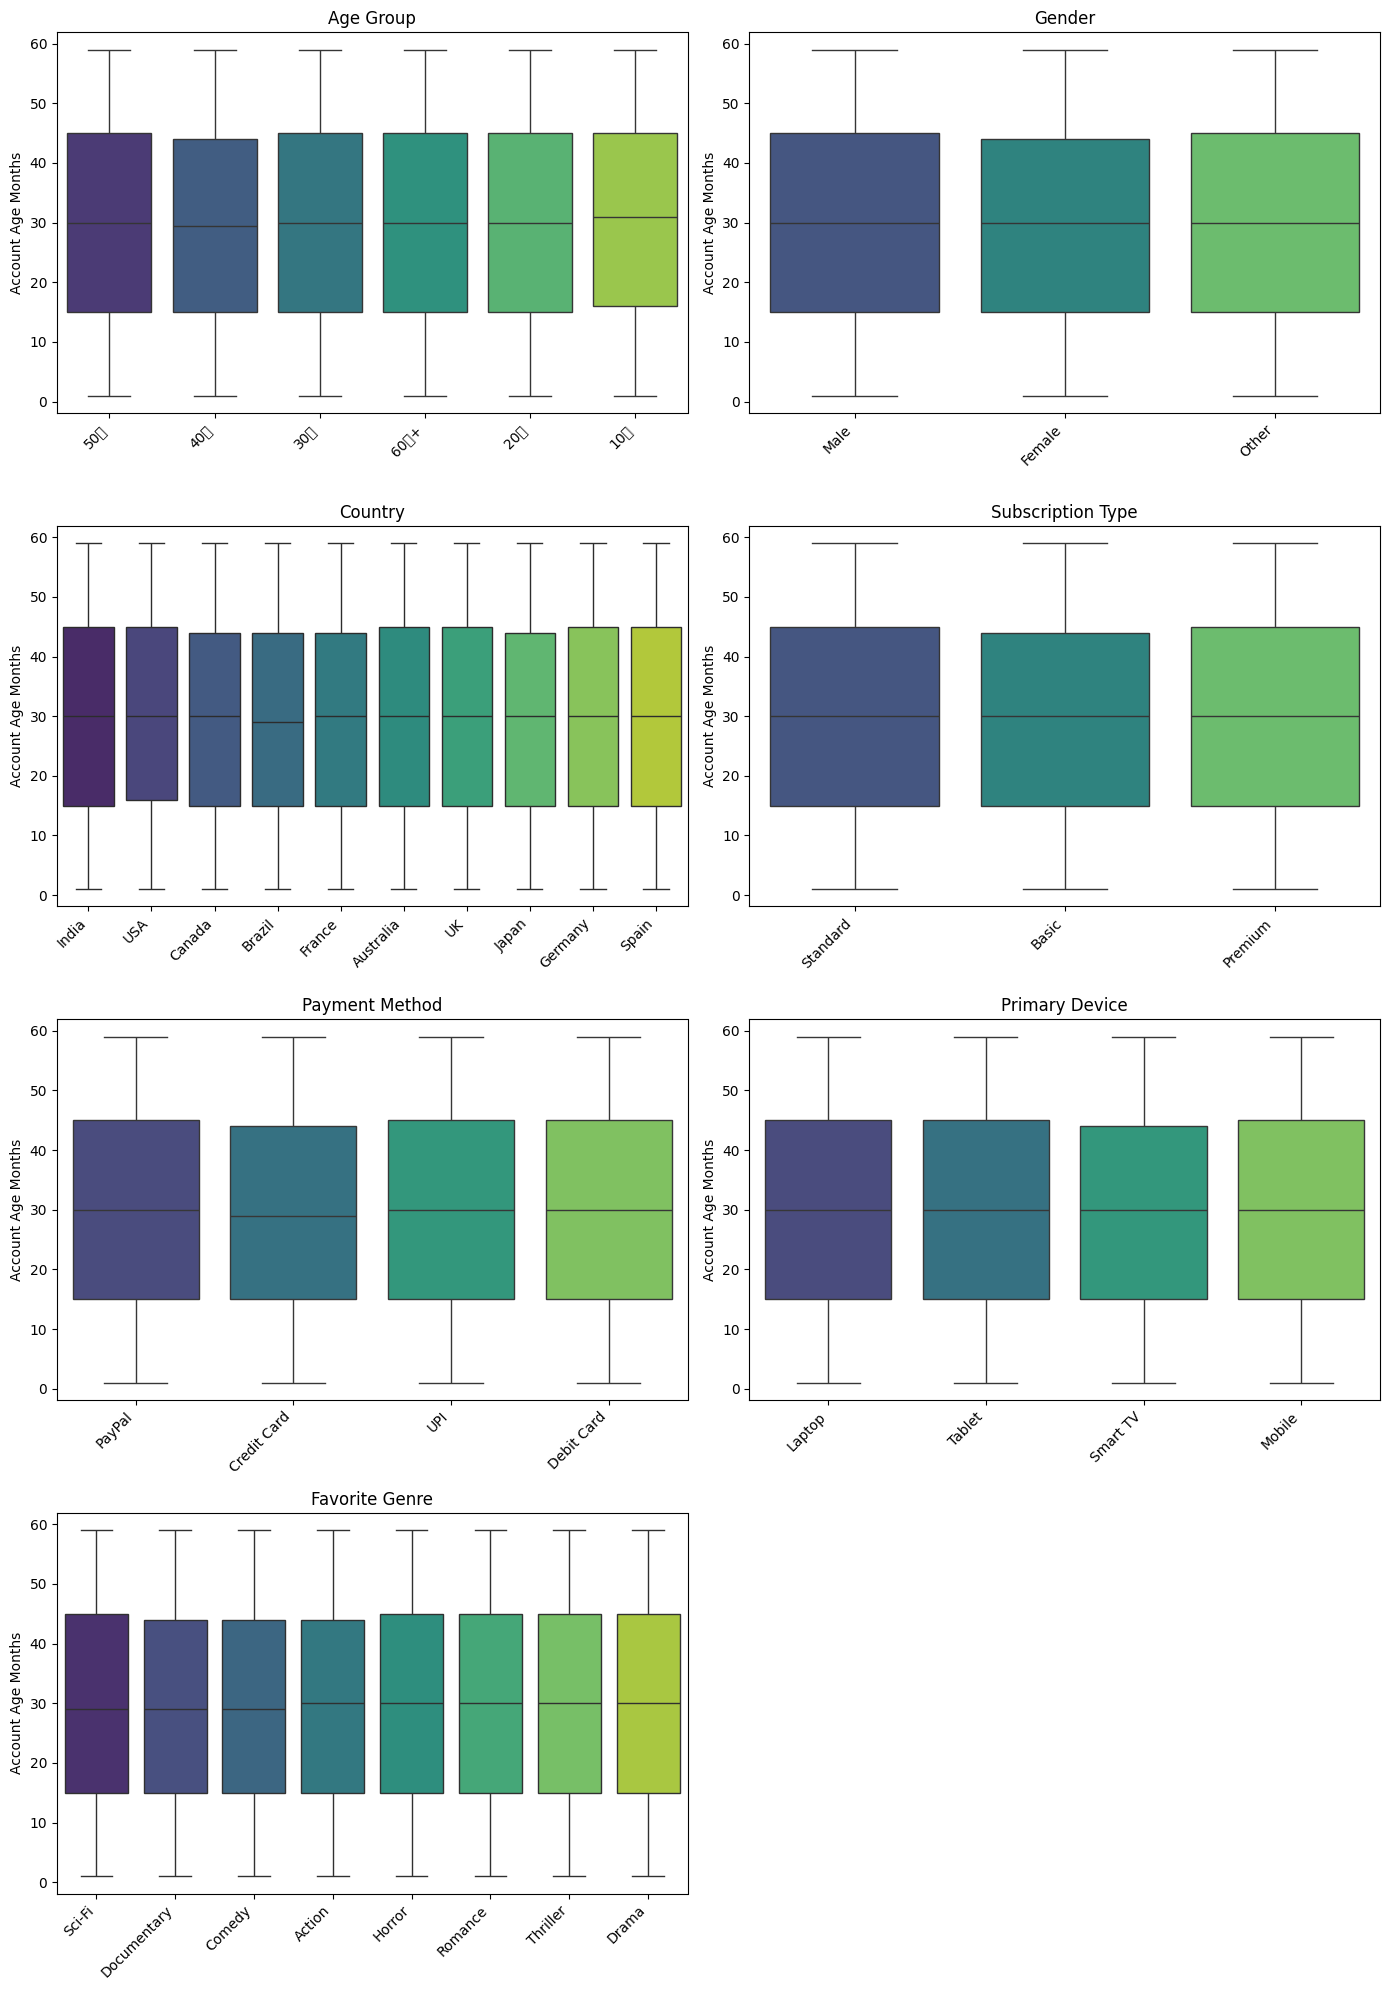

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트 설정 (Colab 환경에서 나눔고딕 설치 및 설정)
# 이미 설치되어 있다면 이 부분은 건너뛸 수 있습니다.
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

plt.rc('font', family='NanumBarunGothic') # 나눔바른고딕으로 설정
plt.rcParams['axes.unicode_minus'] = False # 마이너스 폰트 깨짐 방지

categorical_cols = [
    'age_group',
    'gender',
    'country',
    'subscription_type',
    'payment_method',
    'primary_device',
    'favorite_genre'
]

# Calculate number of rows and columns for subplots
n_cols = 2 # Changed to 2 columns for better visibility
n_rows = (len(categorical_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 7, n_rows * 5)) # Adjust figure size based on new number of columns

for i, col in enumerate(categorical_cols):
    plt.subplot(n_rows, n_cols, i + 1) # Create subplot
    sns.boxplot(x=col, y='account_age_months', data=df2, palette='viridis', hue=col, legend=False)
    plt.title(f'{col.replace("_", " ").title()}')
    plt.xlabel('') # Remove individual x-labels for cleaner look
    plt.ylabel('Account Age Months')
    plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

/tmp/ipykernel_435/4107313264.py:38: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


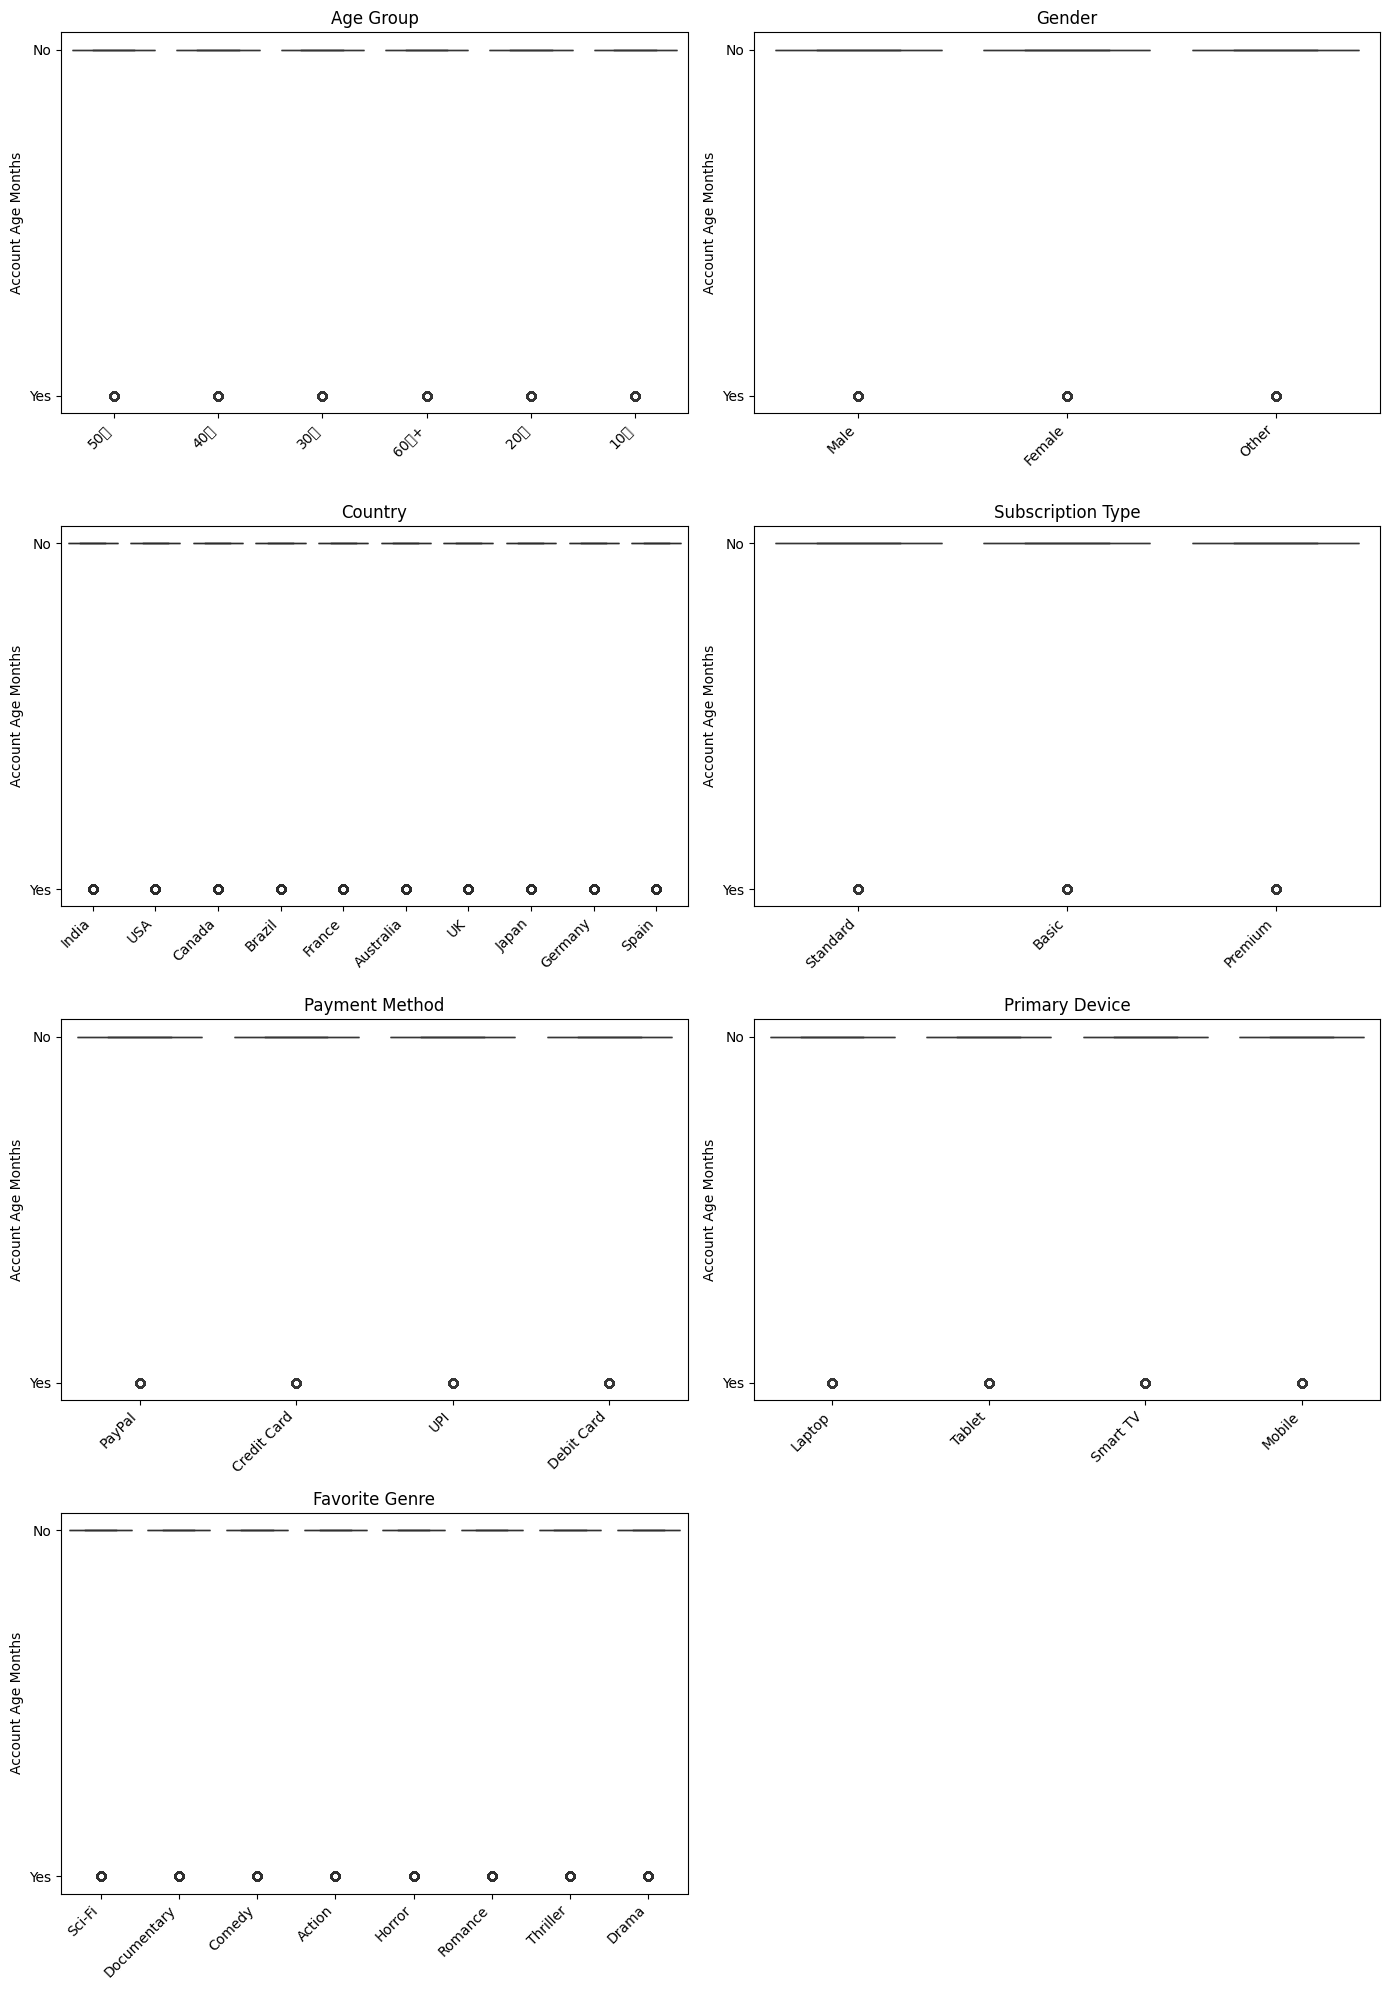

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

plt.rc('font', family='NanumBarunGothic') # 나눔바른고딕으로 설정
plt.rcParams['axes.unicode_minus'] = False # 마이너스 폰트 깨짐 방지

categorical_cols = [
    'age_group',
    'gender',
    'country',
    'subscription_type',
    'payment_method',
    'primary_device',
    'favorite_genre'
]

# Calculate number of rows and columns for subplots
n_cols = 2 # Changed to 2 columns for better visibility
n_rows = (len(categorical_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 7, n_rows * 5)) # Adjust figure size based on new number of columns

for i, col in enumerate(categorical_cols):
    plt.subplot(n_rows, n_cols, i + 1) # Create subplot
    sns.boxplot(x=col, y='churned', data=df2, palette='viridis', hue=col, legend=False)
    plt.title(f'{col.replace("_", " ").title()}')
    plt.xlabel('') # Remove individual x-labels for cleaner look
    plt.ylabel('churned')
    plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

/tmp/ipykernel_435/3337820651.py:35: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


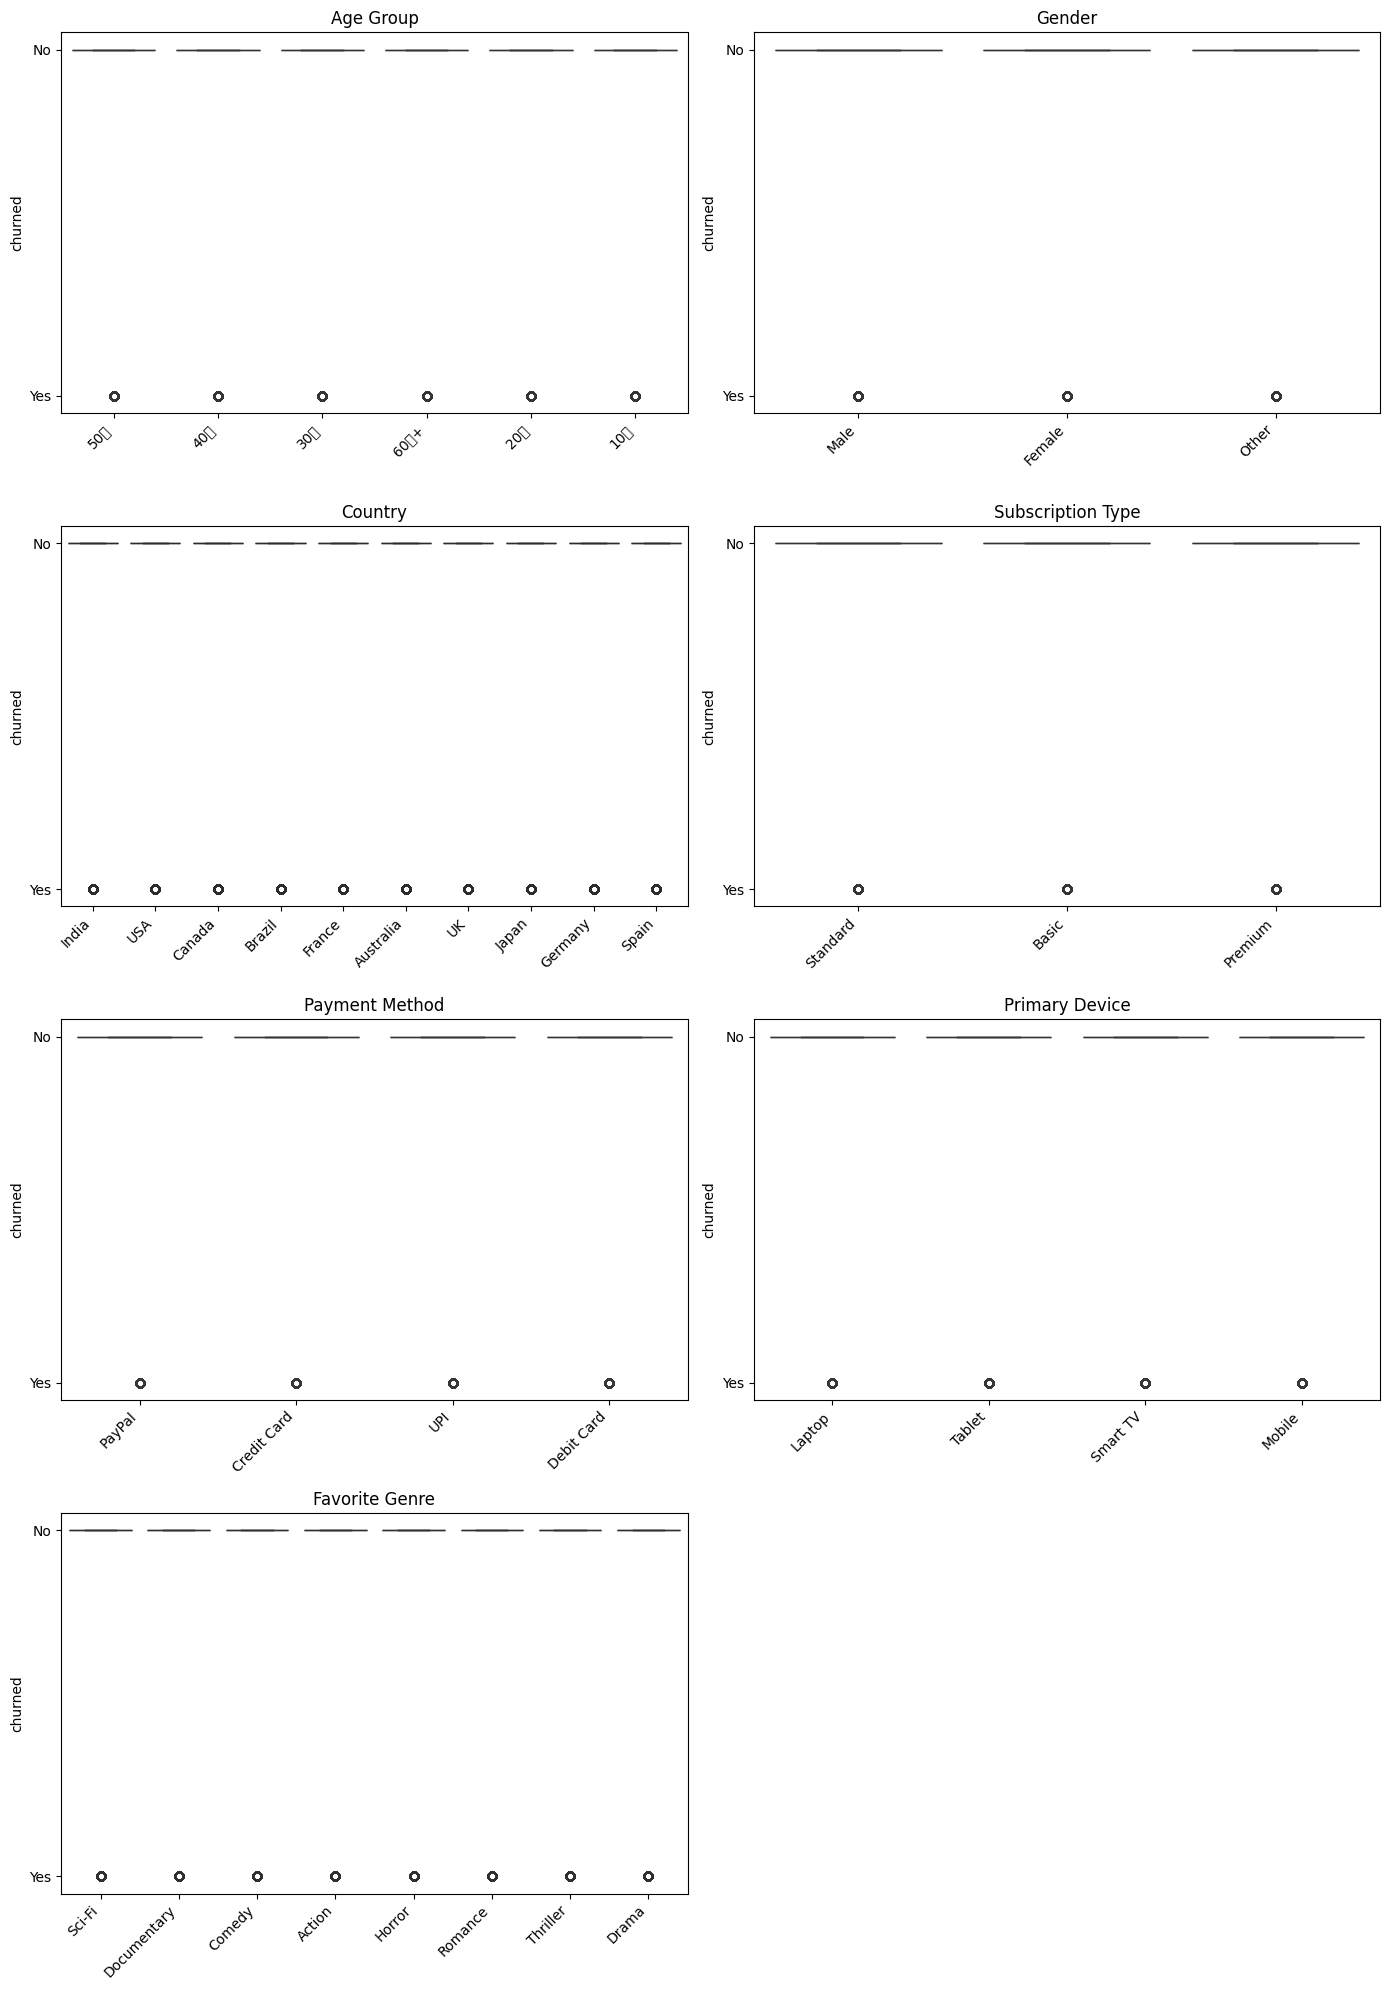

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

plt.rc('font', family='NanumBarunGothic') # 나눔바른고딕으로 설정
plt.rcParams['axes.unicode_minus'] = False # 마이너스 폰트 깨짐 방지

categorical_cols = [
    'age_group',
    'gender',
    'country',
    'subscription_type',
    'payment_method',
    'primary_device',
    'favorite_genre'
]

# Calculate number of rows and columns for subplots
n_cols = 2 # Changed to 2 columns for better visibility
n_rows = (len(categorical_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 7, n_rows * 5)) # Adjust figure size based on new number of columns

for i, col in enumerate(categorical_cols):
    plt.subplot(n_rows, n_cols, i + 1) # Create subplot
    sns.boxplot(x=col, y='churned', data=df2, palette='viridis', hue=col, legend=False)
    plt.title(f'{col.replace("_", " ").title()}')
    plt.xlabel('') # Remove individual x-labels for cleaner look
    plt.ylabel('churned')
    plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

/tmp/ipykernel_435/1193860891.py:36: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


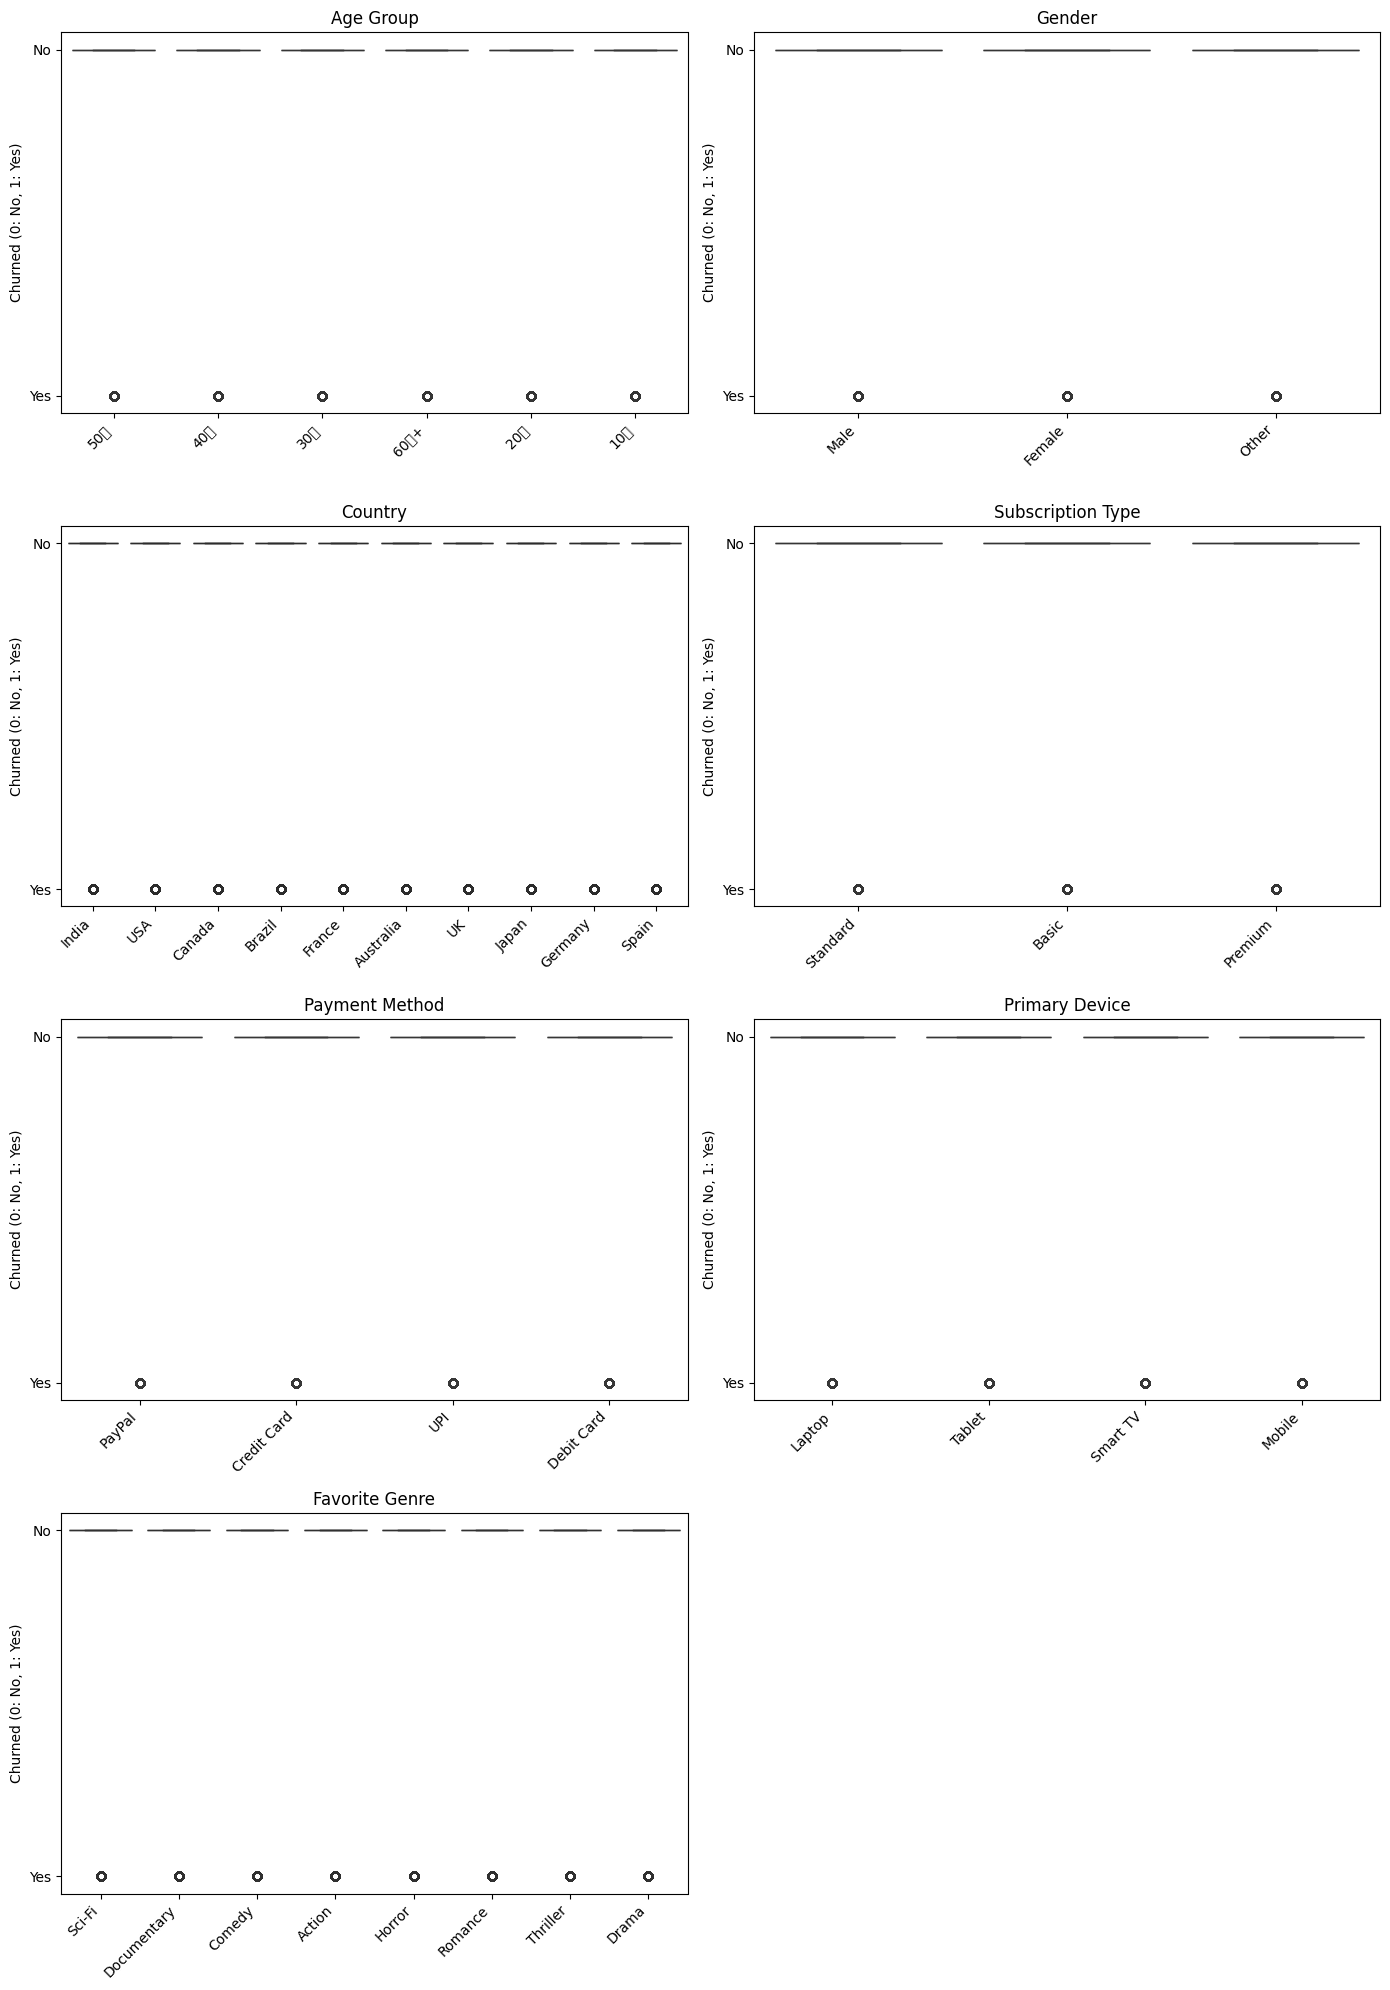

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 폰트 설정 (이전 셀에서 이미 설치되었을 수 있으나, 혹시 모를 경우를 대비하여 다시 포함합니다)
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

plt.rc('font', family='NanumBarunGothic') # 나눔바른고딕으로 설정
plt.rcParams['axes.unicode_minus'] = False # 마이너스 폰트 깨짐 방지

categorical_cols = [
    'age_group',
    'gender',
    'country',
    'subscription_type',
    'payment_method',
    'primary_device',
    'favorite_genre'
]

# Calculate number of rows and columns for subplots
n_cols = 2 # 2열로 변경
n_rows = (len(categorical_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 7, n_rows * 5)) # 피규어 크기 조정

for i, col in enumerate(categorical_cols):
    plt.subplot(n_rows, n_cols, i + 1) # 서브플롯 생성
    sns.boxplot(x=col, y='churned', data=df2, palette='viridis', hue=col, legend=False)
    plt.title(f'{col.replace("_", " ").title()}')
    plt.xlabel('') # X축 라벨 제거
    plt.ylabel('Churned (0: No, 1: Yes)') # Y축 라벨에 설명 추가
    plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [ ]:
# 'churned' 컬럼을 수치형으로 변환 (Yes: 1, No: 0)
df2['churned'] = df2['churned'].map({'Yes': 1, 'No': 0})

# 변환 결과 확인
display(df2.head())

##계정 유지 기간 EDA (y:account_age_months)

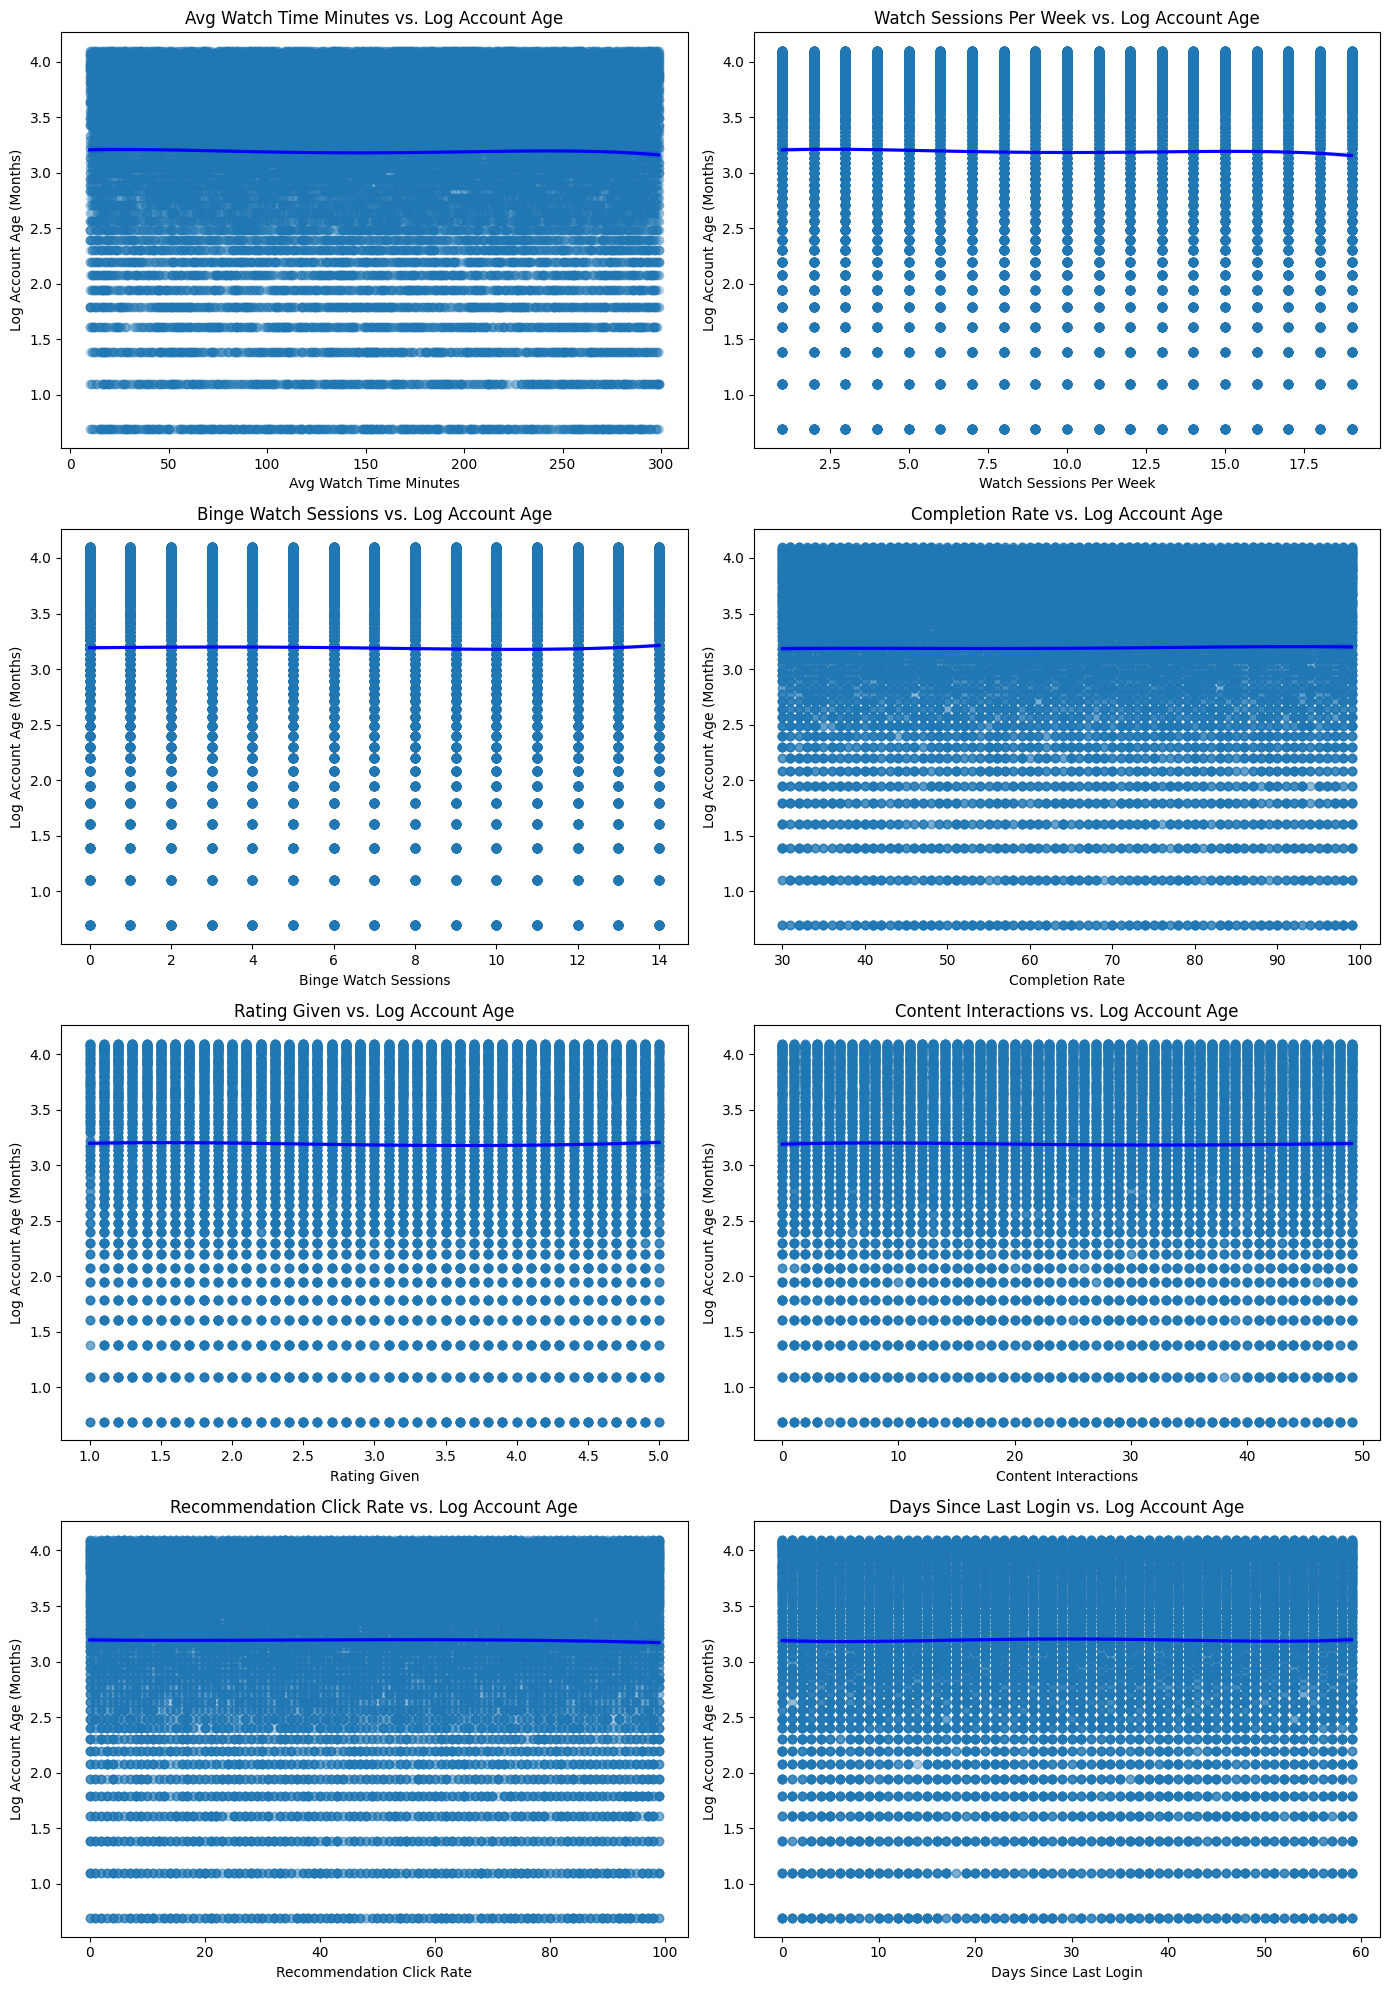

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Ensure df2 is loaded and log_account_age_months is created
# This assumes 'netflix_with_age_group.csv' exists as generated by previous steps.
df2 = pd.read_csv("/content/netflix_with_age_group.csv")
df2['log_account_age_months'] = np.log1p(df2['account_age_months'])

x_cols = [
    'avg_watch_time_minutes',
    'watch_sessions_per_week',
    'binge_watch_sessions',
    'completion_rate',
    'rating_given',
    'content_interactions',
    'recommendation_click_rate',
    'days_since_last_login'
]

# Calculate number of rows for subplots (2 columns per row)
n_cols = 2
n_rows = int(np.ceil(len(x_cols) / n_cols))

plt.figure(figsize=(n_cols * 7, n_rows * 5)) # Adjust figure size

for i, col in enumerate(x_cols):
    plt.subplot(n_rows, n_cols, i + 1) # Create subplot
    sns.regplot(
        x=col,
        y='log_account_age_months', # Using log-transformed account age for consistency
        data=df2,
        order=4, # 4차 곡선
        scatter_kws={'alpha': 0.2},
        line_kws={'color': 'blue'}
    )
    plt.title(f'{col.replace("_", " ").title()} vs. Log Account Age')
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel('Log Account Age (Months)')

plt.tight_layout()
plt.show()



---



#새로운 데이터 로드

In [2]:
import pandas as pd
df2 = pd.read_csv("/content/netflix_with_age_group.csv")
df2

,user_id,age,gender,country,account_age_months,subscription_type,monthly_fee,payment_method,primary_device,devices_used,...,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,completion_rate,rating_given,content_interactions,recommendation_click_rate,days_since_last_login,churned,age_group
0,U100000,56,Male,India,17,Standard,15.99,PayPal,Laptop,1,...,220,17,3,60,1.7,5,66,16,No,50대
1,U100001,46,Female,USA,20,Standard,12.99,PayPal,Tablet,2,...,76,15,4,71,4.6,7,78,14,No,40대
2,U100002,32,Other,USA,25,Basic,15.99,PayPal,Tablet,2,...,215,6,13,33,2.0,27,29,41,No,30대
3,U100003,60,Male,Canada,37,Standard,12.99,PayPal,Smart TV,3,...,280,4,9,58,1.2,9,23,22,No,60대+
4,U100004,25,Male,Brazil,23,Premium,12.99,PayPal,Mobile,3,...,261,15,9,64,1.3,49,56,54,No,20대
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,U149995,60,Female,Japan,30,Standard,15.99,UPI,Tablet,1,...,178,19,1,45,1.8,13,43,8,No,60대+
49996,U149996,46,Other,Brazil,39,Standard,12.99,PayPal,Smart TV,3,...,95,15,5,77,2.1,46,11,30,Yes,40대
49997,U149997,19,Male,UK,53,Basic,7.99,Credit Card,Tablet,3,...,118,18,4,44,2.3,26,17,16,No,10대
49998,U149998,43,Female,UK,19,Standard,7.99,PayPal,Laptop,1,...,280,2,4,44,2.4,12,4,31,No,40대


#가설 검정

###계정 유지 기간 분석 (y: account_age_months)

####로그 변환된 종속 변수를 사용하여 다중 선형 회귀 모델을 다시 실행합니다.

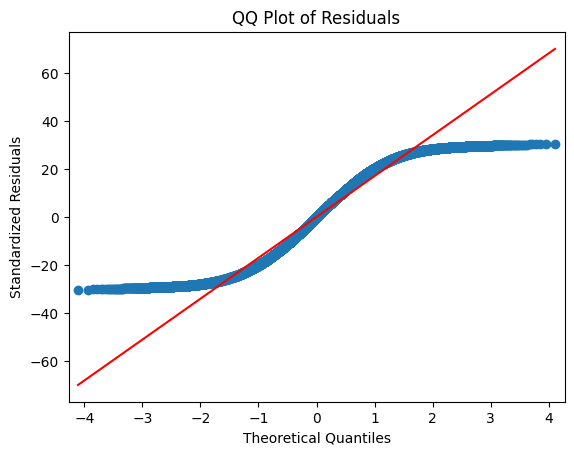

In [ ]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# 잔차 추출
residuals = multimodel.resid

# QQ plot 생성
sm.qqplot(residuals, line='s')
plt.title('QQ Plot of Residuals')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Standardized Residuals')
plt.show()

In [ ]:
import statsmodels.formula.api as smf

multimodel = smf.ols('account_age_months ~ C(age_group) + C(gender) + C(country) + C(primary_device) + C(payment_method) + C(subscription_type) + devices_used + C(favorite_genre) + avg_watch_time_minutes + watch_sessions_per_week + binge_watch_sessions + completion_rate + rating_given + content_interactions + recommendation_click_rate + days_since_last_login', data=df2).fit()
print(multimodel.summary())

                            OLS Regression Results                            
Dep. Variable:     account_age_months   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.9461
Date:                Sat, 02 May 2026   Prob (F-statistic):              0.568
Time:                        05:06:43   Log-Likelihood:            -2.1274e+05
No. Observations:               50000   AIC:                         4.256e+05
Df Residuals:                   49959   BIC:                         4.259e+05
Df Model:                          40                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

In [ ]:
import numpy as np

# 'account_age_months'에 로그 변환 적용
# 0 또는 음수 값에 대한 로그를 방지하기 위해 1을 더합니다.
df2['log_account_age_months'] = np.log1p(df2['account_age_months'])

In [ ]:
import statsmodels.formula.api as smf

multimodel_log = smf.ols('log_account_age_months ~ C(age_group) + C(gender) + C(country) + C(primary_device) + C(payment_method) + C(subscription_type) + devices_used + C(favorite_genre) + avg_watch_time_minutes + watch_sessions_per_week + binge_watch_sessions + completion_rate + rating_given + content_interactions + recommendation_click_rate + days_since_last_login', data=df2).fit()
print(multimodel_log.summary())

                              OLS Regression Results                              
Dep. Variable:     log_account_age_months   R-squared:                       0.001
Model:                                OLS   Adj. R-squared:                 -0.000
Method:                     Least Squares   F-statistic:                    0.9717
Date:                    Sat, 02 May 2026   Prob (F-statistic):              0.521
Time:                            05:12:05   Log-Likelihood:                -60001.
No. Observations:                   50000   AIC:                         1.201e+05
Df Residuals:                       49959   BIC:                         1.204e+05
Df Model:                              40                                         
Covariance Type:                nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------

In [ ]:
import pandas as pd
import numpy as np # numpy import for np.linalg.LinAlgError
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Design matrix 추출 (상수항 포함)
X = multimodel.model.exog
columns = multimodel.model.exog_names

# VIF 계산을 위한 DataFrame 생성
vif_data = pd.DataFrame()
vif_data["feature"] = columns

# 각 변수의 VIF 계산 (상수항 제외)
vif_values = []
for i in range(len(columns)):
    if columns[i] == 'Intercept':
        vif_values.append(float('nan')) # Intercept는 VIF 계산에서 제외
    else:
        try:
            vif_values.append(variance_inflation_factor(X, i))
        except np.linalg.LinAlgError:
            # 다중공선성으로 인해 행렬이 특이점이 되는 경우 무한대 할당
            vif_values.append(float('inf'))
        except Exception as e:
            # 기타 예상치 못한 오류 발생 시 오류 메시지 출력 및 NaN 할당
            print(f"An error occurred for column '{columns[i]}' at index {i}: {e}")
            vif_values.append(float('nan'))
vif_data["VIF"] = vif_values

# VIF 값 기준으로 내림차순 정렬
vif_data = vif_data.sort_values(by="VIF", ascending=False)

print("Variance Inflation Factor (VIF):")
print(vif_data.to_string(index=False))

Variance Inflation Factor (VIF):
                         feature      VIF
             C(age_group)[T.30대] 4.852034
             C(age_group)[T.40대] 4.843771
             C(age_group)[T.20대] 4.791729
             C(age_group)[T.50대] 4.785840
            C(age_group)[T.60대+] 3.161497
            C(country)[T.Brazil] 1.816678
               C(country)[T.USA] 1.812386
             C(country)[T.India] 1.804565
             C(country)[T.Spain] 1.804322
           C(country)[T.Germany] 1.803808
            C(country)[T.Canada] 1.794845
                C(country)[T.UK] 1.790081
            C(country)[T.France] 1.789182
             C(country)[T.Japan] 1.787366
C(favorite_genre)[T.Documentary] 1.763608
    C(favorite_genre)[T.Romance] 1.756474
     C(favorite_genre)[T.Comedy] 1.753931
   C(favorite_genre)[T.Thriller] 1.753755
     C(favorite_genre)[T.Horror] 1.750288
      C(favorite_genre)[T.Drama] 1.749216
     C(favorite_genre)[T.Sci-Fi] 1.747690
     C(payment_method)[T.PayPal] 1.502070
 

#### 상호작용 항(Interaction Terms) 추가

상호작용 항은 두 개 이상의 독립 변수가 종속 변수에 미치는 영향이 서로 결합될 때 사용됩니다. 예를 들어, 특정 연령대에서 성별이 계정 활성 기간에 미치는 영향이 다른 연령대와 다를 수 있습니다. 이러한 상호작용을 모델에 포함하면 모델의 설명력을 높이고 변수 간의 복잡한 관계를 더 잘 포착할 수 있습니다.

In [ ]:
import statsmodels.formula.api as smf

# 기존 모델에 상호작용 항 추가
# 예시: age_group과 gender의 상호작용, watch_sessions_per_week와 avg_watch_time_minutes의 상호작용
# C(age_group):C(gender)는 범주형 변수 간의 상호작용을 나타냅니다.
# watch_sessions_per_week:avg_watch_time_minutes는 연속형 변수 간의 상호작용을 나타냅니다.

multimodel_log_interaction = smf.ols('log_account_age_months ~ C(age_group) * C(gender) + C(country) + C(primary_device) + C(payment_method) + C(subscription_type) + devices_used + C(favorite_genre) + avg_watch_time_minutes * watch_sessions_per_week + binge_watch_sessions + completion_rate + rating_given + content_interactions + recommendation_click_rate + days_since_last_login', data=df2).fit()
print(multimodel_log_interaction.summary())

                              OLS Regression Results                              
Dep. Variable:     log_account_age_months   R-squared:                       0.001
Model:                                OLS   Adj. R-squared:                 -0.000
Method:                     Least Squares   F-statistic:                    0.9329
Date:                    Sat, 02 May 2026   Prob (F-statistic):              0.610
Time:                            05:14:22   Log-Likelihood:                -59997.
No. Observations:                   50000   AIC:                         1.201e+05
Df Residuals:                       49948   BIC:                         1.206e+05
Df Model:                              51                                         
Covariance Type:                nonrobust                                         
                                                     coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------

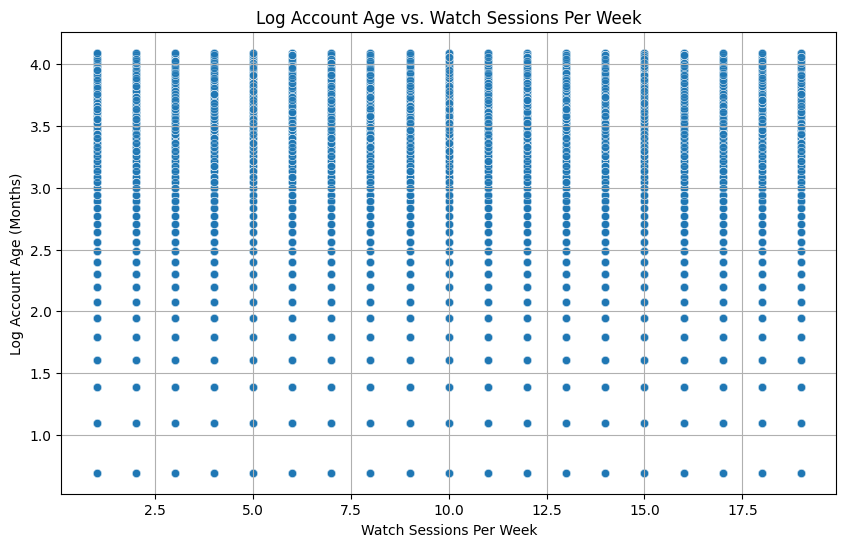

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 'watch_sessions_per_week'와 'log_account_age_months'의 관계 산점도
plt.figure(figsize=(10, 6))
sns.scatterplot(x='watch_sessions_per_week', y='log_account_age_months', data=df2, alpha=0.6)
plt.title('Log Account Age vs. Watch Sessions Per Week')
plt.xlabel('Watch Sessions Per Week')
plt.ylabel('Log Account Age (Months)')
plt.grid(True)
plt.show()

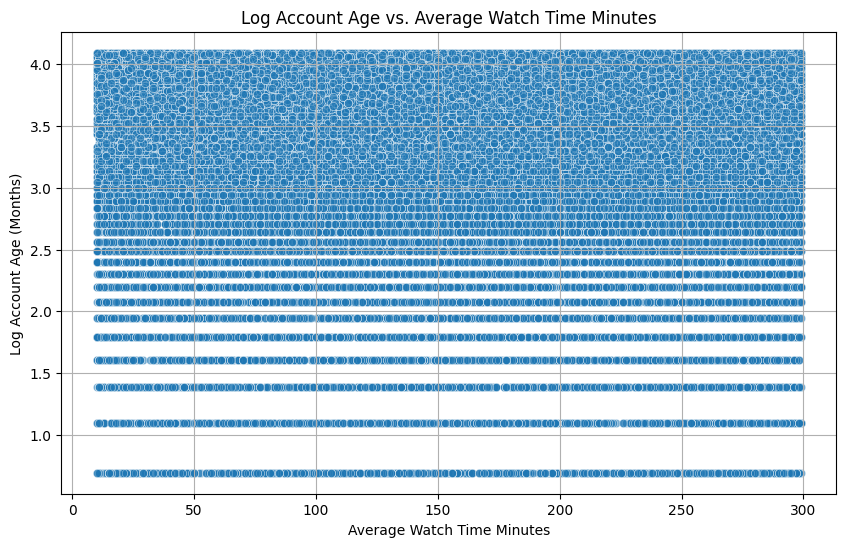

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 'avg_watch_time_minutes'와 'log_account_age_months'의 관계 산점도
plt.figure(figsize=(10, 6))
sns.scatterplot(x='avg_watch_time_minutes', y='log_account_age_months', data=df2, alpha=0.6)
plt.title('Log Account Age vs. Average Watch Time Minutes')
plt.xlabel('Average Watch Time Minutes')
plt.ylabel('Log Account Age (Months)')
plt.grid(True)
plt.show()

####다차항 + Ridge-Lasso
“선형모형의 한계를 보완하기 위해 비선형성과 과적합을 동시에 고려한 다항 회귀 및 규제 기법을 적용하였다.”

In [ ]:
#타겟 선정
y_continuous = df2['account_age_months']

# Define categorical and numerical features for polynomial models
# Exclude 'user_id' as it's an identifier and not a feature
# Exclude 'age' if 'age_group' is used (as 'age_group' is derived from 'age')
# Exclude 'churned' as it's another target variable
# Exclude 'account_age_months' as it's the current target variable
categorical_features_for_poly = [
    'age_group', 'gender', 'country', 'primary_device', 'payment_method',
    'subscription_type', 'favorite_genre'
]
numerical_features_for_poly = [
    'monthly_fee',
    'devices_used',
    'avg_watch_time_minutes',
    'watch_sessions_per_week',
    'binge_watch_sessions',
    'completion_rate',
    'rating_given',
    'content_interactions',
    'recommendation_click_rate',
    'days_since_last_login'
]

# Select and preprocess X for polynomial models
X_poly = df2[numerical_features_for_poly + categorical_features_for_poly].copy()
X_poly = pd.get_dummies(X_poly, columns=categorical_features_for_poly, drop_first=True)

# Assign the processed X to the variable X for consistency with subsequent cells
X = X_poly

In [ ]:
#데이터분리
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_continuous, test_size=0.2, random_state=42
)

In [ ]:
#Polynomial + Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

ridge_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)

print("Ridge R2:", r2_score(y_test, y_pred_ridge))
print("Ridge RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))

Ridge R2: -0.017897159758900383
Ridge RMSE: 17.10776804808807


In [ ]:
#Polynomial + Lasso
from sklearn.linear_model import Lasso

lasso_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('lasso', Lasso(alpha=0.1))
])

lasso_model.fit(X_train, y_train)

y_pred_lasso = lasso_model.predict(X_test)

print("Lasso R2:", r2_score(y_test, y_pred_lasso))
print("Lasso RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))

Lasso R2: -0.0008093355053897522
Lasso RMSE: 16.96356299704889


#### 랜덤 포레스트 모델 적용

선형 회귀 모델의 설명력이 매우 낮았으므로, 비선형 관계를 더 잘 포착할 수 있는 랜덤 포레스트(Random Forest) 회귀 모델을 적용하여 예측력을 평가해 봅니다. 랜덤 포레스트는 여러 개의 결정 트리를 사용하여 예측하는 앙상블 학습 방법으로, 복잡한 데이터 패턴을 학습하는 데 효과적입니다.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# 특징(Features) 및 타겟(Target) 변수 정의
y = df2['log_account_age_months']

categorical_features = ['age_group', 'gender', 'country', 'primary_device', 'payment_method', 'subscription_type', 'favorite_genre']
numerical_features = [
    'devices_used',
    'avg_watch_time_minutes',
    'watch_sessions_per_week',
    'binge_watch_sessions',
    'completion_rate',
    'rating_given',
    'content_interactions',
    'recommendation_click_rate',
    'days_since_last_login'
]

# 데이터프레임에서 불필요한 컬럼 제외하고 features로 설정
# 'user_id'와 'age'는 모델에 직접 사용하지 않으므로 제외합니다.
# 'account_age_months'는 log_account_age_months의 원본이므로 제외합니다.
features = categorical_features + numerical_features
X = df2[features]

# 범주형 변수 원-핫 인코딩
X = pd.get_dummies(X, columns=categorical_features, drop_first=True)

# 훈련 및 테스트 세트 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 랜덤 포레스트 회귀 모델 초기화 및 학습
# n_estimators: 사용할 트리의 개수
# random_state: 재현성 확보를 위한 시드
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1로 모든 코어 사용
rf_model.fit(X_train, y_train)

# 예측
y_pred = rf_model.predict(X_test)

# 모델 평가
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"랜덤 포레스트 모델 MSE: {mse:.4f}")
print(f"랜덤 포레스트 모델 R-squared: {r2:.4f}")

랜덤 포레스트 모델 MSE: 0.6577
랜덤 포레스트 모델 R-squared: -0.0244


###이탈률 분석(y: churned)

####다중선형회귀

In [ ]:
import statsmodels.formula.api as smf

# 'churned' 컬럼을 수치형으로 변환 (Yes: 1, No: 0)
df2['churned'] = df2['churned'].map({'Yes': 1, 'No': 0})

m1 = smf.ols('churned ~ C(age_group) + C(gender) + C(country) + C(primary_device) + C(payment_method) + C(subscription_type) + devices_used + C(favorite_genre) + avg_watch_time_minutes + watch_sessions_per_week + binge_watch_sessions + completion_rate + rating_given + content_interactions + recommendation_click_rate + days_since_last_login', data=df2).fit()
print(m1.summary())

                            OLS Regression Results                            
Dep. Variable:                churned   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.9472
Date:                Sat, 02 May 2026   Prob (F-statistic):              0.566
Time:                        05:23:24   Log-Likelihood:                -25046.
No. Observations:               50000   AIC:                         5.017e+04
Df Residuals:                   49959   BIC:                         5.054e+04
Df Model:                          40                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

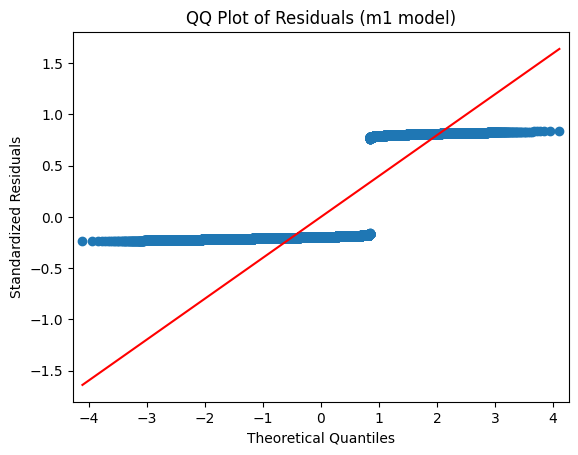

In [ ]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# 잔차 추출
residuals_m1 = m1.resid

# QQ plot 생성
sm.qqplot(residuals_m1, line='s')
plt.title('QQ Plot of Residuals (m1 model)')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Standardized Residuals')
plt.show()

##향후 분석을 위해 다음과 같은 접근 방식을 고려해볼 수 있습니다:





*   **새로운 특징(Feature) 발굴**: 현재사용된 변수 외에 고객의 행동이나 선호도를 더 잘 나타낼 수 있는 새로운 변수들을 탐색하고 모델에 포함해야 합니다. 예를 들어, 특정 콘텐츠 시청 이력, 고객 서비스 문의 횟수, 프로모션 참여 여부 등이 있을 수 있습니다.
*   **외부 데이터 연동**: 고객 행동에 영향을 미칠 수 있는 외부 데이터(예: 경제 지표, 경쟁사 활동)를 추가하는 것을 고려할 수 있습니다.




*   **문제 정의 재검토**: 만약 '계정 활성 기간' 예측이 어렵다면, 문제의 정의를 변경하여 '특정 기간 내 재구독 여부'와 같이 다른 형태의 종속 변수를 고려해볼 수 있습니다.



*  **다른 모델링 기법 고려**: 이탈률 예측과 같이 이진 변수를 예측하는 문제에는 로지스틱 회귀(Logistic Regression), 서포트 벡터 머신(SVM), 그래디언트 부스팅(Gradient Boosting) 등 분류에 특화된 모델들이 더 적합할 수 있습니다. 이러한 모델들은 선형 회귀보다 더 나은 성능을 보일 수 있습니다.






#### 로지스틱 회귀 모델 적용

이탈률 예측은 이진 분류 문제이므로 로지스틱 회귀 모델이 적합합니다. 기존에 선형 회귀 모델에서 사용했던 특징(feature)들을 그대로 활용하여 모델을 구축하고, 모델의 성능을 평가합니다.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd

# 특징(Features) 및 타겟(Target) 변수 정의
y_churn = df2['churned']

categorical_features = [
    'age_group', 'gender', 'country', 'primary_device', 'payment_method',
    'subscription_type', 'favorite_genre'
]
numerical_features = [
    'devices_used',
    'avg_watch_time_minutes',
    'watch_sessions_per_week',
    'binge_watch_sessions',
    'completion_rate',
    'rating_given',
    'content_interactions',
    'recommendation_click_rate',
    'days_since_last_login'
]

# 데이터프레임에서 불필요한 컬럼 제외하고 features로 설정
X_churn = df2[categorical_features + numerical_features]

# 범주형 변수 원-핫 인코딩
X_churn_encoded = pd.get_dummies(X_churn, columns=categorical_features, drop_first=True)

# 훈련 및 테스트 세트 분할
X_train_churn, X_test_churn, y_train_churn, y_test_churn = train_test_split(
    X_churn_encoded, y_churn, test_size=0.2, random_state=42, stratify=y_churn
)

# 로지스틱 회귀 모델 초기화 및 학습
# solver='liblinear'는 작은 데이터셋에 적합하며, 이진 분류에 좋은 성능을 보입니다.
# random_state는 재현성을 위해 설정합니다.
# class_weight='balanced'를 추가하여 클래스 불균형을 처리합니다.
logistic_model = LogisticRegression(solver='liblinear', random_state=42, n_jobs=-1, class_weight='balanced')
logistic_model.fit(X_train_churn, y_train_churn)

# 예측
y_pred_churn = logistic_model.predict(X_test_churn)

# 모델 평가
print("로지스틱 회귀 모델 성능 보고서:")
print(classification_report(y_test_churn, y_pred_churn))
print(f"정확도 (Accuracy): {accuracy_score(y_test_churn, y_pred_churn):.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(


로지스틱 회귀 모델 성능 보고서:
              precision    recall  f1-score   support

           0       0.80      0.51      0.62      8007
           1       0.20      0.48      0.28      1993

    accuracy                           0.50     10000
   macro avg       0.50      0.49      0.45     10000
weighted avg       0.68      0.50      0.55     10000

정확도 (Accuracy): 0.5046


recall이 0.00이었으나, 이제는 0.48로 크게 증가했습니다. 이는 모델이 실제 이탈 고객 중 약 48%를 올바르게 예측하고 있다는 의미입니다.
하지만 이탈 고객 예측에 대한 precision은 0.20으로 낮습니다. 즉, 모델이 이탈할 것이라고 예측한 고객 중 실제로 이탈하는 고객은 20% 정도라는 뜻입니다.

전반적인 accuracy는 0.80에서 0.50으로 감소했지만, 이는 클래스 불균형이 심한 데이터에서 소수 클래스를 더 잘 예측하기 위해 발생하는 일반적인 현상입니다. 이제 모델은 단순히 '대부분의 고객은 이탈하지 않는다'고만 예측하는 것이 아니라, 이탈할 가능성이 있는 고객을 더 적극적으로 식별하려고 노력하고 있습니다.

#### 그래디언트 부스팅 모델 적용

로지스틱 회귀 모델의 성능이 기대에 미치지 못했으므로, 더 복잡한 패턴을 학습할 수 있는 그래디언트 부스팅(Gradient Boosting) 모델을 적용하여 이탈률 예측 성능을 개선해 봅니다. 그래디언트 부스팅은 여러 개의 약한 학습기(보통 결정 트리)를 순차적으로 학습시켜 이전 학습기의 오차를 보완하는 방식으로 작동하며, 강력한 예측 성능을 보이는 앙상블 학습 기법입니다.

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score

# 그래디언트 부스팅 모델 초기화 및 학습
# n_estimators: 부스팅 단계 수 (트리 개수)
# learning_rate: 각 트리의 기여도를 조절하는 학습률
# max_depth: 각 트리의 최대 깊이
# random_state: 재현성 확보를 위한 시드
# class_weight는 GradientBoostingClassifier에서 직접 지원하지 않으므로,
# 샘플 가중치(sample_weight)를 사용하거나, 타겟 클래스 분포를 고려한 다른 접근 방식이 필요할 수 있습니다.
# 여기서는 기본 설정으로 시작합니다.
gradient_boosting_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gradient_boosting_model.fit(X_train_churn, y_train_churn)

# 예측
y_pred_gb = gradient_boosting_model.predict(X_test_churn)

# 모델 평가
print("그래디언트 부스팅 모델 성능 보고서:")
print(classification_report(y_test_churn, y_pred_gb))
print(f"정확도 (Accuracy): {accuracy_score(y_test_churn, y_pred_gb):.4f}")

그래디언트 부스팅 모델 성능 보고서:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89      8007
           1       0.00      0.00      0.00      1993

    accuracy                           0.80     10000
   macro avg       0.40      0.50      0.44     10000
weighted avg       0.64      0.80      0.71     10000

정확도 (Accuracy): 0.8007


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#### SMOTE를 이용한 오버샘플링

그래디언트 부스팅 모델이 이탈 고객을 전혀 예측하지 못한 주요 원인은 심각한 클래스 불균형입니다. 이를 해결하기 위해 SMOTE(Synthetic Minority Over-sampling Technique)를 사용하여 소수 클래스(이탈 고객)의 샘플을 합성하여 훈련 데이터의 균형을 맞춥니다. 이는 모델이 소수 클래스 패턴을 더 잘 학습할 수 있도록 돕습니다.

In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter

print("SMOTE 적용 전 훈련 세트 클래스 분포:", Counter(y_train_churn))

# SMOTE 적용
sm = SMOTE(random_state=42)
X_train_churn_smote, y_train_churn_smote = sm.fit_resample(X_train_churn, y_train_churn)

print("SMOTE 적용 후 훈련 세트 클래스 분포:", Counter(y_train_churn_smote))

SMOTE 적용 전 훈련 세트 클래스 분포: Counter({0: 32029, 1: 7971})
SMOTE 적용 후 훈련 세트 클래스 분포: Counter({1: 32029, 0: 32029})


#### SMOTE 적용 후 그래디언트 부스팅 모델 재학습 및 평가

SMOTE를 통해 클래스 불균형이 해소된 훈련 데이터로 그래디언트 부스팅 모델을 다시 학습하고, 이탈 고객 예측 성능이 어떻게 개선되었는지 평가합니다.

In [ ]:
gradient_boosting_model_smote = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gradient_boosting_model_smote.fit(X_train_churn_smote, y_train_churn_smote)

# 예측
y_pred_gb_smote = gradient_boosting_model_smote.predict(X_test_churn)

# 모델 평가
print("SMOTE 적용 후 그래디언트 부스팅 모델 성능 보고서:")
print(classification_report(y_test_churn, y_pred_gb_smote))
print(f"정확도 (Accuracy): {accuracy_score(y_test_churn, y_pred_gb_smote):.4f}")

SMOTE 적용 후 그래디언트 부스팅 모델 성능 보고서:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89      8007
           1       0.00      0.00      0.00      1993

    accuracy                           0.80     10000
   macro avg       0.40      0.50      0.44     10000
weighted avg       0.64      0.80      0.71     10000

정확도 (Accuracy): 0.8007


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#### LightGBM 모델 적용

Gradient Boosting 모델이 SMOTE 적용 후에도 이탈 고객을 제대로 예측하지 못했으므로, 더 강력하고 클래스 불균형 처리에 유연한 LightGBM (Light Gradient Boosting Machine) 모델을 도입합니다. LightGBM은 XGBoost와 유사한 부스팅 프레임워크지만, 더 빠른 학습 속도와 낮은 메모리 사용량을 가집니다. 특히, `is_unbalance=True` 또는 `scale_pos_weight` 파라미터를 통해 클래스 불균형을 효과적으로 처리할 수 있습니다.

여기서는 `scale_pos_weight` 파라미터를 사용하여 소수 클래스(이탈 고객)에 대한 가중치를 부여하여 모델이 이탈 고객을 더 잘 예측하도록 훈련합니다.

In [ ]:
import lightgbm as lgb
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# 클래스 불균형 비율 계산
# pos_class_weight = (전체 샘플 수 - 소수 클래스 샘플 수) / 소수 클래스 샘플 수
# y_train_churn_smote를 사용하므로, 굳이 계산할 필요 없이 1:1 비율이므로 scale_pos_weight는 1로 설정됩니다.
# 하지만, SMOTE를 사용하지 않고 원본 불균형 데이터로 학습한다면 이 값은 중요합니다.
# 여기서는 SMOTE된 데이터를 사용하므로 scale_pos_weight는 기본값인 1로 두거나, None으로 설정합니다.
# 아니면 원본 y_train_churn을 가지고 계산할 수 있습니다.

# 원본 데이터의 클래스 비율을 사용하려면:
neg_count = Counter(y_train_churn)[0]
pos_count = Counter(y_train_churn)[1]
scale_pos_weight = neg_count / pos_count

print(f"LightGBM의 scale_pos_weight 설정값: {scale_pos_weight:.2f}")

# LightGBM 모델 초기화 및 학습 (SMOTE된 데이터 사용)
# 'objective': 이진 분류 문제이므로 'binary'
# 'metric': 평가 지표로 'binary_logloss'를 사용
# 'is_unbalance': True로 설정하여 불균형 클래스 처리 (또는 scale_pos_weight 사용)
lgb_model = lgb.LGBMClassifier(
    objective='binary',
    metric='binary_logloss',
    n_estimators=200, # 트리 개수 증가
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight # 클래스 불균형 처리
)
lgb_model.fit(X_train_churn_smote, y_train_churn_smote)

# 예측
y_pred_lgb = lgb_model.predict(X_test_churn)

# 모델 평가
print("\nLightGBM 모델 성능 보고서:")
print(classification_report(y_test_churn, y_pred_lgb))
print(f"정확도 (Accuracy): {accuracy_score(y_test_churn, y_pred_lgb):.4f}")

LightGBM의 scale_pos_weight 설정값: 4.02
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 32029, number of negative: 32029
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.024828 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 877
[LightGBM] [Info] Number of data points in the train set: 64058, number of used features: 40
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000

LightGBM 모델 성능 보고서:
              precision    recall  f1-score   support

           0       0.80      0.41      0.54      8007
           1       0.20      0.60      0.30      1993

    accuracy                           0.45     10000
   macro avg       0.50      0.50      0.42     10000
weighted avg       0.68      0.45      0.50     10000

정확도 (Accuracy): 0.4477


#### LightGBM 하이퍼파라미터 튜닝 (RandomizedSearchCV)

LightGBM 모델의 성능을 최적화하기 위해 하이퍼파라미터 튜닝을 진행합니다. `RandomizedSearchCV`는 주어진 하이퍼파라미터 공간에서 무작위로 샘플링하여 교차 검증을 통해 최적의 파라미터를 찾는 방법입니다. 이는 `GridSearchCV`보다 더 효율적으로 넓은 탐색 공간을 커버할 수 있습니다.

주요 튜닝 대상 파라미터는 다음과 같습니다:
*   `n_estimators`: 부스팅 단계(트리)의 수
*   `learning_rate`: 각 트리의 기여도를 조절하는 학습률
*   `num_leaves`: 각 트리의 최대 잎 노드 수
*   `max_depth`: 각 트리의 최대 깊이
*   `min_child_samples`: 잎 노드에 필요한 최소 데이터 수

평가 지표로는 `f1_weighted`를 사용하여 클래스 불균형을 고려한 모델 성능을 측정합니다.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint as sp_randint
from scipy.stats import uniform as sp_uniform

# LightGBM 모델 초기화
lgb_clf = lgb.LGBMClassifier(
    objective='binary',
    metric='binary_logloss',
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight # 클래스 불균형 처리
)

# 튜닝할 하이퍼파라미터 분포 정의
param_dist = {
    'n_estimators': sp_randint(100, 500), # 100에서 500 사이의 트리 개수
    'learning_rate': sp_uniform(0.01, 0.2), # 0.01에서 0.2 사이의 학습률
    'num_leaves': sp_randint(20, 60), # 20에서 60 사이의 잎 노드 수
    'max_depth': sp_randint(5, 15), # 5에서 15 사이의 최대 깊이
    'min_child_samples': sp_randint(20, 100), # 20에서 100 사이의 최소 자식 샘플 수
}

# RandomizedSearchCV 설정
# n_iter: 샘플링할 파라미터 조합의 수
# cv: 교차 검증 폴드 수
# scoring: 모델 평가 지표. f1_weighted는 불균형 클래스에 적합
random_search = RandomizedSearchCV(
    estimator=lgb_clf,
    param_distributions=param_dist,
    n_iter=50, # 탐색할 조합의 수 (시간 제약을 고려하여 조정)
    cv=3, # 3-fold 교차 검증
    scoring='f1_weighted',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# 튜닝 시작 (SMOTE된 훈련 데이터 사용)
print("\nLightGBM 하이퍼파라미터 튜닝 시작...")
random_search.fit(X_train_churn_smote, y_train_churn_smote)
print("LightGBM 하이퍼파라미터 튜닝 완료.")

# 최적의 파라미터와 점수 출력
print(f"\n최적의 하이퍼파라미터: {random_search.best_params_}")
print(f"최고 F1 Weighted Score (훈련 세트 교차 검증): {random_search.best_score_:.4f}")

# 최적의 모델로 예측 및 평가
best_lgb_model = random_search.best_estimator_
y_pred_tuned_lgb = best_lgb_model.predict(X_test_churn)

print("\n튜닝된 LightGBM 모델 성능 보고서 (테스트 세트):")
print(classification_report(y_test_churn, y_pred_tuned_lgb))
print(f"정확도 (Accuracy): {accuracy_score(y_test_churn, y_pred_tuned_lgb):.4f}")


LightGBM 하이퍼파라미터 튜닝 시작...
Fitting 3 folds for each of 50 candidates, totalling 150 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 32029, number of negative: 32029
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.024200 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 877
[LightGBM] [Info] Number of data points in the train set: 64058, number of used features: 40
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
LightGBM 하이퍼파라미터 튜닝 완료.

최적의 하이퍼파라미터: {'learning_rate': np.float64(0.18198808134726413), 'max_depth': 11, 'min_child_samples': 40, 'n_estimators': 428, 'num_leaves': 58}
최고 F1 Weighted Score (훈련 세트 교차 검증): 0.7321

튜닝된 LightGBM 모델 성능 보고서 (테스트 세트):
              precision    recall  f1-score   support

           0       0.80    

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score
import lightgbm as lgb

# ---------------------------
# 1. 데이터 분리
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_churn_encoded, y_churn, test_size=0.2, random_state=42, stratify=y_churn
)

# ---------------------------
# 2. 불균형 비율 계산
# ---------------------------
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos

# ---------------------------
# 3. 모델 정의
# ---------------------------
model = lgb.LGBMClassifier(
    objective='binary',
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

# ---------------------------
# 4. 하이퍼파라미터 (최소한만)
# ---------------------------
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [5, 10],
}

# ---------------------------
# 5. GridSearch (f1 기준)
# ---------------------------
grid = GridSearchCV(
    model,
    param_grid,
    scoring='f1',  # f1 스코어로 변경
    cv=3,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("최적 파라미터:", grid.best_params_)

# ---------------------------
# 6. 예측 (확률 기반)
# ---------------------------
best_model = grid.best_estimator_

y_prob = best_model.predict_proba(X_test)[:, 1]

# ---------------------------
# 7. threshold 조정 (중요)
# ---------------------------
threshold = 0.3  # ⭐ 낮추면 recall 올라감
y_pred = (y_prob >= threshold).astype(int)

# ---------------------------
# 8. 평가
# ---------------------------
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 7971, number of negative: 32029
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003554 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 663
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 40
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.199275 -> initscore=-1.390832
[LightGBM] [Info] Start training from score -1.390832
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

### 비지도 학습 (Unsupervised Learning): K-Means 클러스터링

지도 학습 모델의 설명력이 낮았으므로, 고객 데이터를 기반으로 자연스러운 그룹(세그먼트)을 발견하기 위해 K-Means 클러스터링을 적용해 봅니다. 이는 고객 행동 패턴을 이해하고, 이탈 위험이 높은 그룹이나 특정 특성을 가진 그룹을 식별하는 데 도움이 될 수 있습니다.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np

# 클러스터링을 위한 특징 변수 정의
# 'churned'는 예측 대상이었으므로 클러스터링 특징에서는 제외 (단, 클러스터링 후 분석에 활용 가능)
# 'user_id'는 식별자이므로 제외
# 'age_group'은 이미 생성된 범주형 변수이므로 사용

clustering_features_cat = ['age_group', 'gender', 'country', 'primary_device', 'payment_method', 'subscription_type', 'favorite_genre']
clustering_features_num = [
    'account_age_months',
    'devices_used',
    'avg_watch_time_minutes',
    'watch_sessions_per_week',
    'binge_watch_sessions',
    'completion_rate',
    'rating_given',
    'content_interactions',
    'recommendation_click_rate',
    'days_since_last_login'
]

# df2의 복사본을 사용하여 데이터 준비 (원본 df2 변경 방지)
df_clustering = df2.copy()

# 범주형 변수 원-핫 인코딩
df_clustering_encoded = pd.get_dummies(df_clustering[clustering_features_cat], columns=clustering_features_cat, drop_first=True)

# 수치형 변수 선택
df_clustering_numerical = df_clustering[clustering_features_num]

# 인코딩된 범주형 변수와 수치형 변수 병합
X_clustering = pd.concat([df_clustering_numerical, df_clustering_encoded], axis=1)

# 데이터 스케일링 (K-Means는 스케일에 민감)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clustering)

# 스케일링된 데이터를 DataFrame으로 변환
X_scaled_df = pd.DataFrame(X_scaled, columns=X_clustering.columns)

print("클러스터링을 위한 데이터 준비 완료. 스케일링된 데이터의 처음 5행:")
display(X_scaled_df.head())


클러스터링을 위한 데이터 준비 완료. 스케일링된 데이터의 처음 5행:


,account_age_months,devices_used,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,completion_rate,rating_given,content_interactions,recommendation_click_rate,days_since_last_login,...,payment_method_UPI,subscription_type_Premium,subscription_type_Standard,favorite_genre_Comedy,favorite_genre_Documentary,favorite_genre_Drama,favorite_genre_Horror,favorite_genre_Romance,favorite_genre_Sci-Fi,favorite_genre_Thriller
0,-0.755032,-1.221100,0.776976,1.279628,-0.923138,-0.224358,-1.130192,-1.334429,0.570398,-0.774626,...,-0.577227,-0.660770,1.228273,-0.378275,-0.381481,-0.376339,-0.377031,-0.379069,2.660611,-0.378206
1,-0.579089,0.001051,-0.942910,0.914702,-0.692499,0.320030,1.386522,-1.196192,0.986823,-0.890152,...,-0.577227,-0.660770,1.228273,-0.378275,2.621362,-0.376339,-0.377031,-0.379069,-0.375854,-0.378206
2,-0.285849,0.001051,0.717258,-0.727466,1.383254,-1.560583,-0.869842,0.186179,-0.713579,0.669438,...,-0.577227,-0.660770,-0.814151,2.643576,-0.381481,-0.376339,-0.377031,-0.379069,-0.375854,-0.378206
3,0.417924,1.223202,1.493596,-1.092392,0.460697,-0.323338,-1.564108,-1.057955,-0.921792,-0.428051,...,-0.577227,-0.660770,1.228273,-0.378275,-0.381481,-0.376339,-0.377031,-0.379069,-0.375854,-0.378206
4,-0.403145,1.223202,1.266666,0.914702,0.460697,-0.026399,-1.477325,1.706788,0.223377,1.420352,...,-0.577227,1.513387,-0.814151,-0.378275,-0.381481,-0.376339,2.652303,-0.379069,-0.375854,-0.378206


K-Means 클러스터링 완료 (클러스터 수: 3)
클러스터별 데이터 수:
cluster_label
0    10556
1    10794
2    28650
Name: count, dtype: int64
실루엣 점수 (Silhouette Score): 0.0450

클러스터별 수치형 특징 및 이탈률 평균:


,account_age_months,devices_used,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,completion_rate,rating_given,content_interactions,recommendation_click_rate,days_since_last_login,churned
cluster_label,,,,,,,,,,,
0,29.887078,1.988253,155.608090,10.021315,7.050777,64.066787,2.992497,24.450360,49.564418,29.376942,0.200265
1,29.908746,2.010932,154.545210,10.016583,6.973967,64.730128,3.014258,24.223365,49.997591,29.441264,0.199463
2,29.856091,1.998709,154.853962,9.963072,6.995497,64.631239,3.001435,24.284607,49.398743,29.411309,0.198848


/tmp/ipykernel_3394/3937659180.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='cluster_label', y='churned', data=churn_rate_by_cluster, palette='viridis')


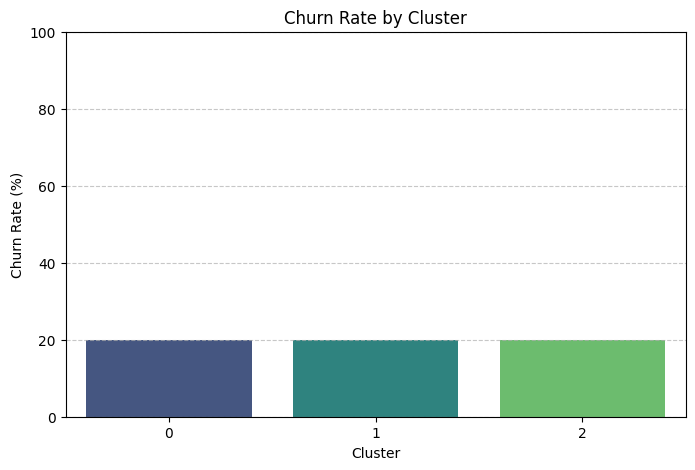

In [ ]:
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# K-Means 클러스터링 적용 (예시로 3개의 클러스터)
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init을 10으로 설정
df_clustering['cluster_label'] = kmeans.fit_predict(X_scaled)

print(f"K-Means 클러스터링 완료 (클러스터 수: {k})")
print("클러스터별 데이터 수:")
print(df_clustering['cluster_label'].value_counts().sort_index())

# 실루엣 점수 계산
sil_score = silhouette_score(X_scaled, df_clustering['cluster_label'])
print(f"실루엣 점수 (Silhouette Score): {sil_score:.4f}")

# 클러스터별 특징 분석 (평균값)
cluster_means = df_clustering.groupby('cluster_label')[clustering_features_num + ['churned']].mean()
print("\n클러스터별 수치형 특징 및 이탈률 평균:")
display(cluster_means)

# 각 클러스터에 대한 churned 비율 시각화
churn_rate_by_cluster = df_clustering.groupby('cluster_label')['churned'].mean().reset_index()
churn_rate_by_cluster['churned'] = churn_rate_by_cluster['churned'] * 100 # 퍼센트로 변환

plt.figure(figsize=(8, 5))
sns.barplot(x='cluster_label', y='churned', data=churn_rate_by_cluster, palette='viridis')
plt.title('Churn Rate by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


#### 선형판별분석(Linear Discriminant Analysis, LDA) 모델 적용

이진 분류 문제에 적용할 수 있는 또 다른 모델인 선형판별분석(LDA)을 사용해봅니다. LDA는 각 클래스의 분포를 모델링하고, 이 분포를 기반으로 클래스를 분류하는 선형 결합을 찾습니다. 클래스 불균형에 대한 고려도 함께 진행합니다.

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import numpy as np
from collections import Counter

# 특징(Features) 및 타겟(Target) 변수 정의는 이미 되어 있는 X_churn_encoded와 y_churn을 사용합니다.

# 훈련 및 테스트 세트 분할
# LightGBM과 동일하게 stratify=y_churn을 사용하여 클래스 비율 유지
X_train_lda, X_test_lda, y_train_lda, y_test_lda = train_test_split(
    X_churn_encoded, y_churn, test_size=0.2, random_state=42, stratify=y_churn
)

# 클래스 불균형 비율 계산
# LDA는 기본적으로 class_weight를 지원하지 않으므로, 데이터 전처리(SMOTE)나 샘플 가중치를 고려해야 합니다.
# 여기서는 우선 불균형 비율을 확인합니다.
neg_count_lda = Counter(y_train_lda)[0]
pos_count_lda = Counter(y_train_lda)[1]
print(f"훈련 세트 클래스 분포: {Counter(y_train_lda)}")
print(f"긍정 클래스 (1) 비율: {pos_count_lda / (neg_count_lda + pos_count_lda) * 100:.2f}%")

# LDA 모델 초기화 및 학습
# LDA는 기본적으로 클래스 비율을 학습 과정에서 고려하지만, 불균형이 심한 경우 성능이 저하될 수 있습니다.
lda_model = LinearDiscriminantAnalysis()
lda_model.fit(X_train_lda, y_train_lda)

# 예측
y_pred_lda = lda_model.predict(X_test_lda)

# 예측 확률 (ROC-AUC 계산용)
y_prob_lda = lda_model.predict_proba(X_test_lda)[:, 1]

# 모델 평가
print("\n--- LDA 모델 성능 보고서 ---")
print(classification_report(y_test_lda, y_pred_lda))
print(f"정확도 (Accuracy): {accuracy_score(y_test_lda, y_pred_lda):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test_lda, y_prob_lda):.4f}")

NameError: name 'X_churn_encoded' is not defined